# Q3: Disparities in Outcomes
When looking at disposed of (i.e. closed/not pending) shooting cases in which someone was shot, how do outcomes and sentences compare for Latino defendants versus for white or non-Latino defendants?

In [ ]:
import pandas as pd
from cryptorandom.cryptorandom import SHA256
from scipy.stats import fisher_exact
from scipy.stats.contingency import odds_ratio
import numpy as np
import seaborn as sns

sns.set_theme()

import os
os.chdir('../')
from utils import chi2, permutation

seed = 98066
prng = SHA256(seed)

In [2]:
# data loading
df = pd.read_csv("example-1/example_1_data_sanitized.csv")

In [3]:
df_filtered = df[(df["Open  = 0; Closed =1"]==1) & (df["Someone shot? (0=no, 1=yes)"]==1) & (df["Exclude?"].isnull()) ].reset_index(drop=True)

In [4]:
prison = lambda row: row["State prison Prison?"] # returns 1 if they went to county or state prison

In [5]:
# filter for sentenced, race
df_filtered["prison"] = df_filtered.apply(prison, axis=1).astype(int)
df_filtered = df_filtered[["Docket", "prison", "Probation", "Dismissal?", "Prison in months", "Race"]]

In [6]:
df_white_hispanic = df_filtered[df_filtered["Race"].isin(["W", "H"])].reset_index(drop=True)
df_non_hispanic = df_filtered
df_non_hispanic["race"] = [ "H" if race == "H" else "NH" for race in df_non_hispanic["Race"].to_list()]

# In disposed of cases, are Latino defendants more frequently sentenced to prison compared to white or non-latino defendants?

**Tests**: fishers/permutation, risk ratio, odds ratio

## Latino v White

In [7]:
df_race_prison_white_hispanic = df_white_hispanic[["Race", "prison", "Docket"]]

In [8]:
contingency_white_hispanic = pd.crosstab(df_race_prison_white_hispanic["Race"], df_race_prison_white_hispanic["prison"])
contingency_white_hispanic

prison,0,1
Race,,
H,2,17
W,8,8


In [9]:
# risk ratio
(contingency_white_hispanic.at["H", 1]  / (contingency_white_hispanic.at["H", 0] + contingency_white_hispanic.at["H", 1] ))/ \
(contingency_white_hispanic.at["W", 1]  / (contingency_white_hispanic.at["W", 0] + contingency_white_hispanic.at["W", 1] ))

np.float64(1.7894736842105263)

In [10]:
# odds ratio
table = contingency_white_hispanic[[1,0]].T # reformat to gets odds of prison
result = odds_ratio(table)
print(f"The odds of a Hispanic defendant who shot someone to be sentenced to prison is {round(result.statistic,3)} \n \
      times higher than a White defendant who also shot someone")


The odds of a Hispanic defendant who shot someone to be sentenced to prison is 7.944 
       times higher than a White defendant who also shot someone


In [11]:
# fishers exact 
# null hypothesis: hispanics and whites are sentenced to prison at the same rate
# alternative hypothesis: hispanics are sentenced to prison at a greater rate than whites
res = fisher_exact(table, alternative='greater')
print(f"p-value: {round(res.pvalue,5)}, test stat: {res.statistic}")

p-value: 0.01322, test stat: 8.5


/opt/anaconda3/envs/rja/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


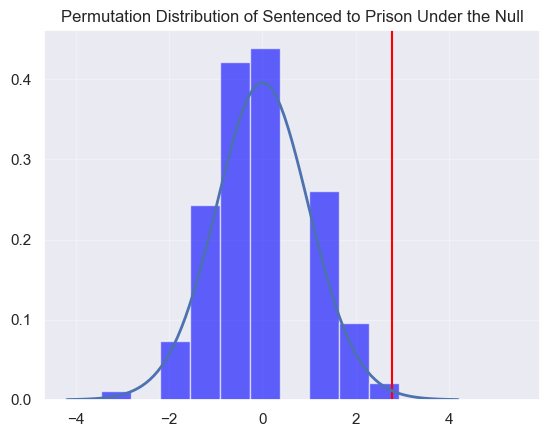

p-value: 0.0149, test stat: 2.77746


In [12]:
# permutation proportion - assumption under null is race can be randomly selected
# null hypothesis: hispanics and whites are sentenced to prison at the same proportion
# alternative hypothesis: hispanics are sentenced to prison at a greater proportion than whites
h_prison, w_prison = permutation.get_lists(df_race_prison_white_hispanic, "Race", "H", "W", "prison")
_ = permutation.t_test(h_prison, w_prison, "greater", prng=prng, title="Sentenced to Prison")

In [13]:
# n_h = len(df_race_prison_white_hispanic[df_race_prison_white_hispanic["Race"]=="H"]) # number we sample in each step
# obs_stat = contingency_white_hispanic.at["H", 1]/n_h # proportion of hispanics sentenced to prison
# def test_stat(df): 
#     return df["prison"].mean()
# _, _ = permutation.prop_test(n_h, df_race_prison_white_hispanic, test_stat, obs_stat, prng=prng, plot_title="Sentenced to Prison", tail="greater")

### Latino v Non-Latino

In [14]:
# filter for sentenced, race
df_race_prison_non_hispanic = df_non_hispanic[["race", "prison", "Docket"]]

In [15]:
contingency_non_hispanic = pd.crosstab(df_race_prison_non_hispanic["race"], df_race_prison_non_hispanic["prison"])
contingency_non_hispanic

prison,0,1
race,,
H,2,17
NH,25,27


In [16]:
# risk ratio
(contingency_non_hispanic.at["H", 1]  / (contingency_non_hispanic.at["H", 0] + contingency_non_hispanic.at["H", 1] ))/ \
(contingency_non_hispanic.at["NH", 1]  / (contingency_non_hispanic.at["NH", 0] + contingency_non_hispanic.at["NH", 1] ))

np.float64(1.7231968810916178)

In [17]:
# odds ratio
table = contingency_non_hispanic[[1,0]].T # reformat to gets odds of prison
result = odds_ratio(table)
print(f"The odds of a Hispanic defendant who shot someone to be sentenced to prison is {round(result.statistic,3)} \n \
      times higher than a Non-Hispanic defendant who also shot someone")


The odds of a Hispanic defendant who shot someone to be sentenced to prison is 7.674 
       times higher than a Non-Hispanic defendant who also shot someone


In [18]:
# fishers exact 
# null hypothesis: hispanics and non-hispanics are sentenced to prison at the same rate
# alternative hypothesis: hispanics are sentenced to prison at a greater rate than non-hispanics
res = fisher_exact(table, alternative='greater')
print(f"p-value: {round(res.pvalue,5)}, test stat: {res.statistic}")

p-value: 0.00312, test stat: 7.87037037037037


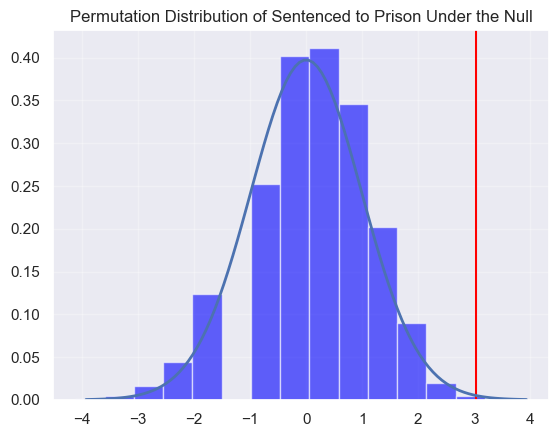

p-value: 0.0019, test stat: 3.02759


In [19]:
# permutation proportion - assumption under null is race can be randomly selected
# null hypothesis: hispanics and non-hispanics are sentenced to prison at the same proportion
# alternative hypothesis: hispanics are sentenced to prison at a greater proportion than non-hispanics
h_prison, nh_prison = permutation.get_lists(df_race_prison_non_hispanic, "race", "H", "NH", "prison")
_ = permutation.t_test(h_prison, nh_prison, "greater", prng=prng, title="Sentenced to Prison")


In [20]:
# def test_stat(df): 
#     return df["prison"].mean()
# n_h = len(df_race_prison_non_hispanic[df_race_prison_non_hispanic["race"]=="H"]) # number we sample in each step
# obs_stat = contingency_non_hispanic.at["H", 1]/n_h # proportion of hispanics sentenced to prison
#_, _ = permutation.prop_test(n_h, df_race_prison_non_hispanic, test_stat, obs_stat, prng=prng, plot_title="Sentenced to Prison", tail="greater")

# In disposed of cases, are Latino defendants less frequently sentenced to probation compared to white or non-latino defendants?

**Tests**: fishers/permutation proportion, risk ratio

### Latino v White

In [21]:
df_race_prob_white_hispanic = df_white_hispanic[["Race", "Probation", "Docket"]]

In [22]:
contingency_white_hispanic = pd.crosstab(df_race_prob_white_hispanic["Race"], df_race_prob_white_hispanic["Probation"])
contingency_white_hispanic

Probation,0.0,1.0
Race,,
H,17,2
W,11,5


In [23]:
# risk ratio
(contingency_white_hispanic.at["H", 1]  / (contingency_white_hispanic.at["H", 0] + contingency_white_hispanic.at["H", 1] ))/ \
(contingency_white_hispanic.at["W", 1]  / (contingency_white_hispanic.at["W", 0] + contingency_white_hispanic.at["W", 1] ))

np.float64(0.3368421052631579)

In [24]:
# risk ratio
(contingency_white_hispanic.at["H", 0]  / (contingency_white_hispanic.at["H", 0] + contingency_white_hispanic.at["H", 1] ))/ \
(contingency_white_hispanic.at["W", 0]  / (contingency_white_hispanic.at["W", 0] + contingency_white_hispanic.at["W", 1] ))

np.float64(1.3014354066985645)

In [25]:
# odds ratio
table = contingency_white_hispanic.T # reformat to gets odds of probation
result = odds_ratio(table)
print(f"The odds of a Hispanic defendant who shot someone to not be sentenced to probation is {round(result.statistic,3)} \n \
      times higher than a White defendant who also shot someone")


The odds of a Hispanic defendant who shot someone to not be sentenced to probation is 3.714 
       times higher than a White defendant who also shot someone


In [26]:
table.reindex([1.0, 0.0])

Race,H,W
Probation,,
1.0,2,5
0.0,17,11


In [27]:
# fishers exact 
# null hypothesis: hispanics and whites are sentenced to probation at the same rate
# alternative hypothesis: hispanics are sentenced to probation at a lesser rate than whites
res = fisher_exact(table.reindex([1.0, 0.0]), alternative='less')
print(f"p-value: {round(res.pvalue,5)}, test stat: {round(res.statistic, 5)}")

p-value: 0.1354, test stat: 0.25882


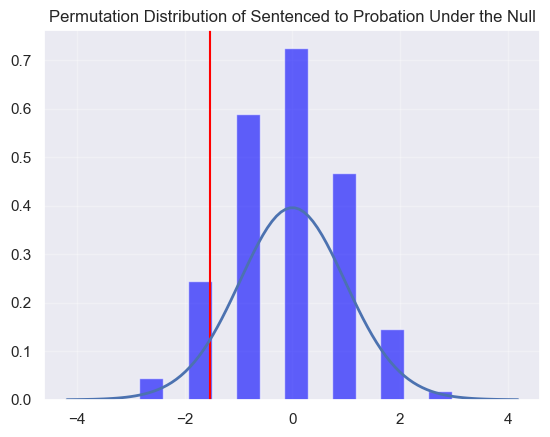

p-value: 0.13119, test stat: -1.53462


In [28]:
# permutation proportion - assumption under null is race can be randomly selected
# null hypothesis: hispanics and whites are sentenced to probation at the same proportion
# alternative hypothesis: hispanics are sentenced to probation at a lesser rate than whites
h_prob, w_prob = permutation.get_lists(df_race_prob_white_hispanic, "Race", "H", "W", "Probation")
_ = permutation.t_test(h_prob, w_prob, "less", prng=prng, title="Sentenced to Probation")

In [29]:
# def test_stat(df): 
#     return df["Probation"].mean()

# n_h = len(df_race_prob_white_hispanic[df_race_prob_white_hispanic["Race"]=="H"]) # number we sample in each step
# obs_stat = contingency_white_hispanic.at["H", 1]/n_h # proportion of hispanics sentenced to prison
# _, _ = permutation.prop_test(n_h, df_race_prob_white_hispanic, test_stat, obs_stat, prng=prng, plot_title="Sentenced to Probation", tail="less")

### Latino v Non-Latino

In [30]:
# filter for sentenced, race
df_race_prob_non_hispanic = df_non_hispanic[["race", "Probation", "Docket"]]

In [31]:
contingency_non_hispanic = pd.crosstab(df_race_prob_non_hispanic["race"], df_race_prob_non_hispanic["Probation"])
contingency_non_hispanic

Probation,0.0,1.0
race,,
H,17,2
NH,38,14


In [32]:
# risk ratio
(contingency_non_hispanic.at["H", 0]  / (contingency_non_hispanic.at["H", 0] + contingency_non_hispanic.at["H", 1] ))/ \
(contingency_non_hispanic.at["NH", 0]  / (contingency_non_hispanic.at["NH", 0] + contingency_non_hispanic.at["NH", 1] ))

np.float64(1.2243767313019391)

In [33]:
# risk ratio
(contingency_non_hispanic.at["H", 1]  / (contingency_non_hispanic.at["H", 0] + contingency_non_hispanic.at["H", 1] ))/ \
(contingency_non_hispanic.at["NH", 1]  / (contingency_non_hispanic.at["NH", 0] + contingency_non_hispanic.at["NH", 1] ))

np.float64(0.39097744360902253)

In [34]:
# odds ratio
table = contingency_non_hispanic.T # reformat to gets odds of prison
result = odds_ratio(table)
print(f"The odds of a Hispanic defendant who shot someone to not be sentenced to probation is {round(result.statistic,3)} \n \
      times higher than a Non-Hispanic defendant who also shot someone")


The odds of a Hispanic defendant who shot someone to not be sentenced to probation is 3.089 
       times higher than a Non-Hispanic defendant who also shot someone


In [35]:
# fishers exact 
# null hypothesis: hispanics and non-hispanics are sentenced to probation at the same rate
# alternative hypothesis: hispanics are sentenced to probation at a lesser rate than non-hispanics
res = fisher_exact(table.reindex([1.0, 0.0]), alternative='less')
print(f"p-value: {round(res.pvalue,5)}, test stat: {res.statistic}")

p-value: 0.12431, test stat: 0.31932773109243695


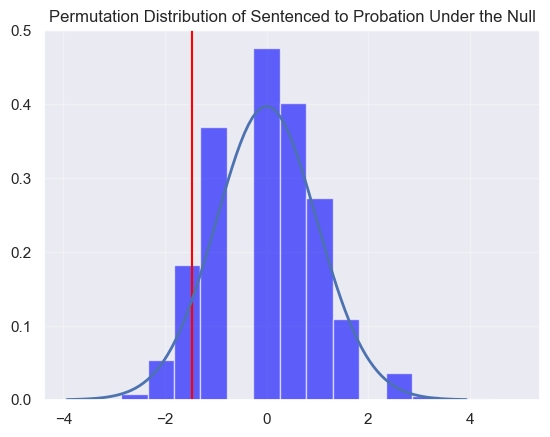

p-value: 0.11799, test stat: -1.46546


In [36]:
# permutation proportion - assumption under null is race can be randomly selected
# null hypothesis: hispanics and non-hispanics get probation at the same proportion
# alternative hypothesis: hispanics are sentenced to probation at a lesser proportion than non-hispanics
h_prob, nh_prob = permutation.get_lists(df_race_prob_non_hispanic, "race", "H", "NH", "Probation")
_ = permutation.t_test(h_prob, nh_prob, "less", prng=prng, title="Sentenced to Probation")


In [37]:
# def test_stat(df): 
#     return df["Probation"].mean()
# n_h = len(df_race_prob_non_hispanic[df_race_prob_non_hispanic["race"]=="H"]) # number we sample in each step
# obs_stat = contingency_non_hispanic.at["H", 1]/n_h # proportion of hispanics sentenced to prison
# _, _ = permutation.prop_test(n_h, df_race_prob_non_hispanic, test_stat, obs_stat, prng=prng, plot_title="Sentenced to Probation", tail="less")

## In disposed of cases, do Latino defendants less frequently obtain a dismissal of their case as compare to white or non-Latino defendants?

**Tests**: chi-squares/fishers/permutation, risk ratio
 
### Latino v White

In [38]:
df_race_dis_white_hispanic = df_white_hispanic[["Race", "Dismissal?", "Docket"]]

In [39]:
contingency_white_hispanic = pd.crosstab(df_race_dis_white_hispanic["Race"], df_race_dis_white_hispanic["Dismissal?"])
contingency_white_hispanic

Dismissal?,0.0,1.0
Race,,
H,19,0
W,13,3


In [40]:
# risk ratio
(contingency_white_hispanic.at["H", 0]  / (contingency_white_hispanic.at["H", 0] + contingency_white_hispanic.at["H", 1] ))/ \
(contingency_white_hispanic.at["W", 0]  / (contingency_white_hispanic.at["W", 0] + contingency_white_hispanic.at["W", 1] ))

np.float64(1.2307692307692308)

In [41]:
# odds ratio
table = contingency_white_hispanic.T # reformat to gets odds of probation
result = odds_ratio(table)
print(f"The odds of a Hispanic defendant who shot someone to not be dismissed is {round(result.statistic,3)} \n \
      times higher than a Hispanic defendant who also shot someone")


The odds of a Hispanic defendant who shot someone to not be dismissed is inf 
       times higher than a Hispanic defendant who also shot someone


In [42]:
# fishers exact 
# null hypothesis: hispanics and whites are dismissed at the same rate
# alternative hypothesis: hispanics are dismissed at a lesser rate than whites
res = fisher_exact(table.reindex([1.0, 0.0]), alternative='less')
print(f"p-value: {round(res.pvalue,5)}, test stat: {round(res.statistic, 5)}")

p-value: 0.08556, test stat: 0.0


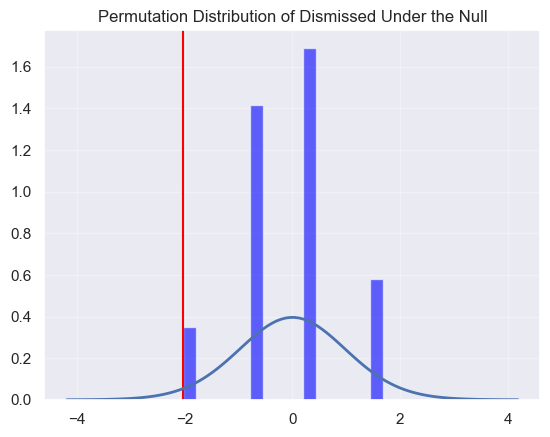

p-value: 0.08689, test stat: -2.03324


In [43]:
# permutation proportion - assumption under null is race can be randomly selected
# null hypothesis: hispanics and whites are dismissed at the same proportion
# alternative hypothesis: hispanics are dismissed at a lesser rate than whites
h_dis, w_dis = permutation.get_lists(df_race_dis_white_hispanic, "Race", "H", "W", "Dismissal?")
_ = permutation.t_test(h_dis, w_dis, "less", prng=prng, title="Dismissed")

In [44]:
# n_h = len(df_race_dis_white_hispanic[df_race_prob_white_hispanic["Race"]=="H"]) # number we sample in each step
# obs_stat = contingency_white_hispanic.at["H", 1]/n_h # proportion of hispanics sentenced to prison
# def test_stat(df): 
#     return df["Dismissal?"].mean()
# _, _ = permutation.prop_test(n_h, df_race_dis_white_hispanic, test_stat, obs_stat, prng=prng, plot_title="Dismissed", tail="less")

### Latino v Non-Latino

In [45]:
# filter for sentenced, race
df_race_dis_non_hispanic = df_non_hispanic[["race", "Dismissal?", "Docket"]]

In [46]:
contingency_non_hispanic = pd.crosstab(df_race_dis_non_hispanic["race"], df_race_dis_non_hispanic["Dismissal?"])
contingency_non_hispanic

Dismissal?,0.0,1.0
race,,
H,19,0
NH,42,10


In [47]:
# risk ratio
(contingency_non_hispanic.at["H", 0]  / (contingency_non_hispanic.at["H", 0] + contingency_non_hispanic.at["H", 1] ))/ \
(contingency_non_hispanic.at["NH", 0]  / (contingency_non_hispanic.at["NH", 0] + contingency_non_hispanic.at["NH", 1] ))

np.float64(1.2380952380952381)

In [48]:
contingency_non_hispanic.T

race,H,NH
Dismissal?,,
0.0,19,42
1.0,0,10


In [49]:
# odds ratio
table = contingency_non_hispanic.T # reformat to gets odds of prison
result = odds_ratio(table) # issue bc 0 in denom
print(f"The odds of a Hispanic defendant who shot someone to be dismissed is {round(result.statistic,3)} \n \
      times higher than a Non-Hispanic defendant who also shot someone")


The odds of a Hispanic defendant who shot someone to be dismissed is inf 
       times higher than a Non-Hispanic defendant who also shot someone


In [50]:
# fishers exact 
# null hypothesis: hispanics and non-hispanics have cases dismissed at the same rate
# alternative hypothesis: hispanics cases are dismissed at a lower rate than non-hispanics
res = fisher_exact(table.reindex([1.0, 0.0]), alternative='less')
print(f"p-value: {round(res.pvalue,5)}, test stat: {res.statistic}")

p-value: 0.03426, test stat: 0.0


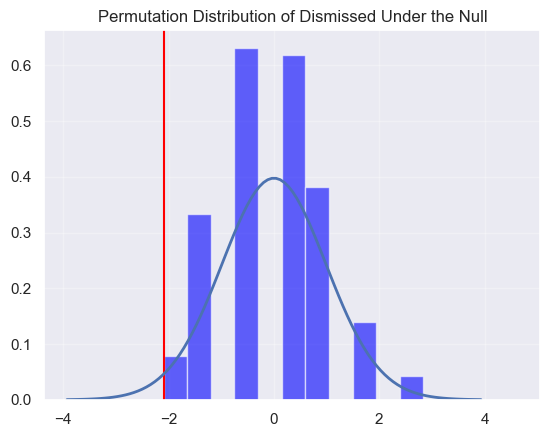

p-value: 0.0354, test stat: -2.09675


In [51]:
# permutation proportion - assumption under null is race can be randomly selected
# null hypothesis: hispanics and non-hispanics are dismissed at the same proportion
# alternative hypothesis: hispanics are dismissed at a lower proportion than non-hispanics
h_dis, nh_dis = permutation.get_lists(df_race_dis_non_hispanic, "race", "H", "NH", "Dismissal?")
_ = permutation.t_test(h_dis, nh_dis, "less", prng=prng, title="Dismissed")


In [52]:
# n_h = len(df_race_prison_non_hispanic[df_race_dis_non_hispanic["race"]=="H"]) # number we sample in each step
# obs_stat = contingency_non_hispanic.at["H", 1]/n_h # proportion of hispanics sentenced to prison
# def test_stat(df): 
#     return df["Dismissal?"].mean()
# _, _ = permutation.prop_test(n_h, df_race_dis_non_hispanic, test_stat, obs_stat, prng=prng, plot_title="Dismissed", tail="less")

# On average, are Latino defendants sentenced to prison sentenced to a longer prison term compared to white defendants sentenced to prison?

**Tests**: 2 - permutation


In [53]:
prison_sentences = df_white_hispanic[df_race_prison_white_hispanic["prison"]==1][["Race", "Prison in months"]]

17


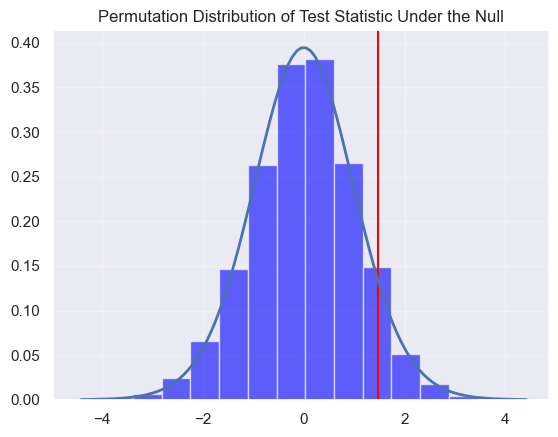

p-value: 0.07589, test stat: 1.47004


In [54]:
white = prison_sentences[prison_sentences["Race"]=="W"]["Prison in months"].tolist()
hispanic = prison_sentences[prison_sentences["Race"]=="H"]["Prison in months"].tolist()
print(len(hispanic))
_,_,_ = permutation.t_test(hispanic, white, "greater", prng=prng)

In [55]:
print(f"On averages, Whites sentenced to prison are sentanced for {round(np.mean(white),3)} months and Hispanics sentenced to prison are sentenced for {round(np.mean(hispanic),3)} months")

On averages, Whites sentenced to prison are sentanced for 82.5 months and Hispanics sentenced to prison are sentenced for 126.941 months


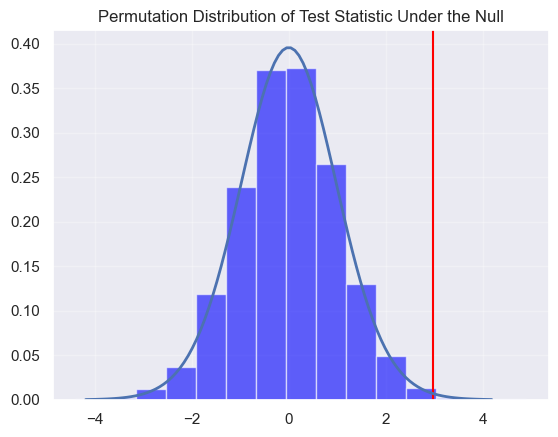

p-value: 0.0029, test stat: 2.96635
On averages, Whites sentenced to prison are sentanced for 41.25 months and Hispanics sentenced to prison are sentenced for 113.579 months


In [56]:
prison_sentences = df_white_hispanic[["Race", "Prison in months"]]
white = prison_sentences[prison_sentences["Race"]=="W"]["Prison in months"].tolist()
hispanic = prison_sentences[prison_sentences["Race"]=="H"]["Prison in months"].tolist()
_,_,_ = permutation.t_test(hispanic, white, "greater", prng=prng)
print(f"On averages, Whites sentenced to prison are sentanced for {round(np.mean(white),3)} months and Hispanics sentenced to prison are sentenced for {round(np.mean(hispanic),3)} months")

# How does the average sentence for Latino defendants charged with a shooting compare to the average sentence for white or non-Latino defendants charged with a shooting?

* might need clarification on this question vs the previous

**Tests**: 2 - permutation

In [57]:
prison_sentences = df_non_hispanic[df_race_prison_non_hispanic["prison"]==1][["race", "Prison in months"]]

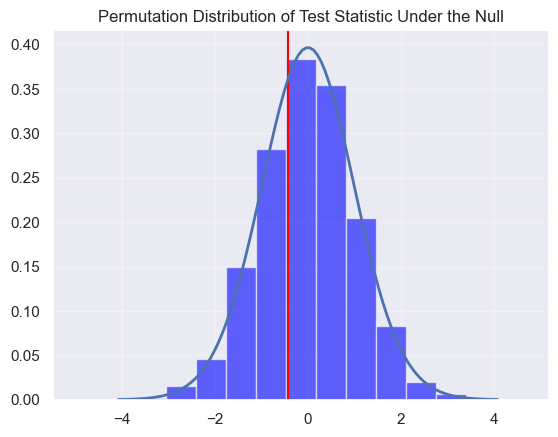

p-value: 0.66173, test stat: -0.42069


In [58]:
non_hispanic = prison_sentences[prison_sentences["race"]=="NH"]["Prison in months"].tolist()
hispanic = prison_sentences[prison_sentences["race"]=="H"]["Prison in months"].tolist()
_,_,_ = permutation.t_test(hispanic, non_hispanic, "greater", prng=prng)

In [59]:
print(f"On averages, Non-Hispanics sentenced to prison are sentanced for {round(np.mean(non_hispanic),3)} months and Hispanics sentenced to prison are sentenced for {round(np.mean(hispanic),3)} months")

On averages, Non-Hispanics sentenced to prison are sentanced for 136.0 months and Hispanics sentenced to prison are sentenced for 126.941 months


In [60]:
prison_sentences = df_non_hispanic[["race", "Prison in months"]]

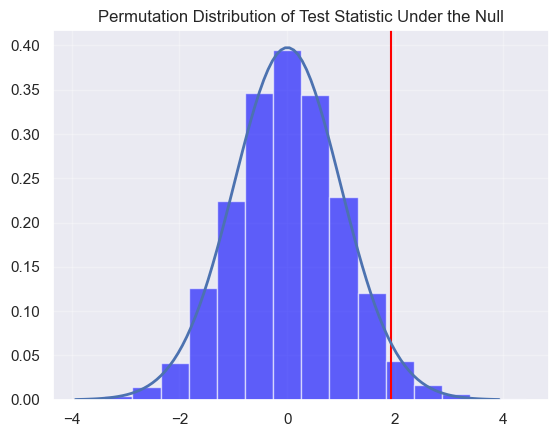

p-value: 0.0309, test stat: 1.92255


In [61]:
non_hispanic = prison_sentences[prison_sentences["race"]=="NH"]["Prison in months"].tolist()
hispanic = prison_sentences[prison_sentences["race"]=="H"]["Prison in months"].tolist()
_,_,_ = permutation.t_test(hispanic, non_hispanic, "greater", prng=prng)

In [62]:
print(f"On averages, Non-Hispanics sentenced to prison are sentanced for {round(np.mean(non_hispanic),3)} months and Hispanics sentenced to prison are sentenced for {round(np.mean(hispanic),3)} months")

On averages, Non-Hispanics sentenced to prison are sentanced for 71.077 months and Hispanics sentenced to prison are sentenced for 113.579 months
